In [1]:
from time_series_gan.WGAN import WGAN
import numpy as np
import pandas as pd
from time_series_gan.metrics import dWasserstein, dFrechet, ONND, score
from Optimisation_MH import generer_resultats, Metropolis_Hasting

c:\Users\sducr\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv("data/data_gdp.csv")

In [ ]:
archi = Metropolis_Hasting(0.1, data, WGAN, ite = 1000, metrique=score, nom_de_la_métrique = "score")

fit took 5.833677 seconds
MH étape : 0
ajout d'une couche au critic
fit took 3.189057 seconds
succes
5.357748320361431 ->  5.212817213546054

{'lr_g': 0.001, 'lr_c': 0.001, 'epochs': 100, 'batch_size': 32, 'latent_dim': 20, 'n_critic': 2, 'lambda_gp': 0.1}
generator : [1]        ReLU
critic : [62, 1]        ReLU


MH étape : 1
suppression d'une couche du generator
fit took 2.081878 seconds
echec


MH étape : 2
suppression d'une couche du critic
fit took 1.298227 seconds
echec


MH étape : 3
ajout d'une couche au critic
fit took 3.317359 seconds
echec


MH étape : 4
ajout d'une couche au generator
fit took 2.616758 seconds
echec


MH étape : 5
modification de la fonction d'activation du generator
fit took 2.208128 seconds
echec


MH étape : 6
modification des paramètres
fit took 2.965793 seconds
succes
5.212817213546054 ->  4.586375709330605

{'lr_g': 0.0009965, 'lr_c': 0.0008104, 'epochs': 150, 'batch_size': 55, 'latent_dim': 23, 'n_critic': 2, 'lambda_gp': 0.254}
generator : [1]      

In [3]:
params = {'lr_g': 0.001751, 'lr_c': 0.000813, 'epochs': 50, 'batch_size': 68, 'latent_dim': 46, 'n_critic': 2, 'lambda_gp': 0.549}

# print(archi)
archi = {'generator': {'architecture': 'MLP', 'layer_sizes': [1], 'activation': 'ReLU'}, 'critic': {'architecture': 'MLP', 'layer_sizes': [62, 1], 'activation': 'ReLU'}}

In [4]:
model = WGAN()
model.set_data(data)
model.fit(architectures = archi, params = params)

fit took 5.650573 seconds


{}

In [6]:
n = 20

w = np.array([model.compute_val_metric(dWasserstein, {}) for _ in range(n)])
f = np.array([model.compute_val_metric(dFrechet, {}) for _ in range(n)])
o = np.array([model.compute_val_metric(ONND, {}) for _ in range(n)])
s = np.array([model.compute_val_metric(score, {}) for _ in range(n)])

print("Wasserstein", w.mean(), w.std())
print("Fréchet", f.mean(), f.std())
print("ONND", o.mean(), o.std())
print("Score", s.mean(), s.std())

Wasserstein 0.36928385410295406 0.11563678304633405
Fréchet 1.4113398569295212 0.5781653253175254
ONND 0.15415542217112763 0.06364713193768122
Score 5.279164410660443 1.6245444548391337


Epoch [1/50], C Loss: 0.0822, G Loss: 0.4493, Dwasserstein: 0.3448, Dfrechet: 1.0021, Onnd: 0.3079, Score: 5.2632
Epoch [2/50], C Loss: -0.0660, G Loss: 0.3634, Dwasserstein: 0.5921, Dfrechet: 1.5566, Onnd: 0.2516, Score: 6.0989
Epoch [3/50], C Loss: -0.0095, G Loss: 0.4459, Dwasserstein: 0.3621, Dfrechet: 1.4305, Onnd: 0.1374, Score: 4.2315
Epoch [4/50], C Loss: 0.1265, G Loss: 0.3631, Dwasserstein: 0.4119, Dfrechet: 2.3031, Onnd: 0.1566, Score: 4.5624
Epoch [5/50], C Loss: -0.0418, G Loss: 0.2641, Dwasserstein: 0.4079, Dfrechet: 1.3288, Onnd: 0.1147, Score: 5.0772
Epoch [6/50], C Loss: -0.0508, G Loss: 0.5652, Dwasserstein: 0.5963, Dfrechet: 1.6454, Onnd: 0.2218, Score: 6.3760
Epoch [7/50], C Loss: 0.0297, G Loss: 0.3647, Dwasserstein: 0.3825, Dfrechet: 1.4512, Onnd: 0.1186, Score: 3.8937
Epoch [8/50], C Loss: 0.0827, G Loss: 0.2305, Dwasserstein: 0.3605, Dfrechet: 1.3164, Onnd: 0.2579, Score: 6.8562
Epoch [9/50], C Loss: 0.1809, G Loss: 0.4734, Dwasserstein: 0.5209, Dfrechet: 1.2278

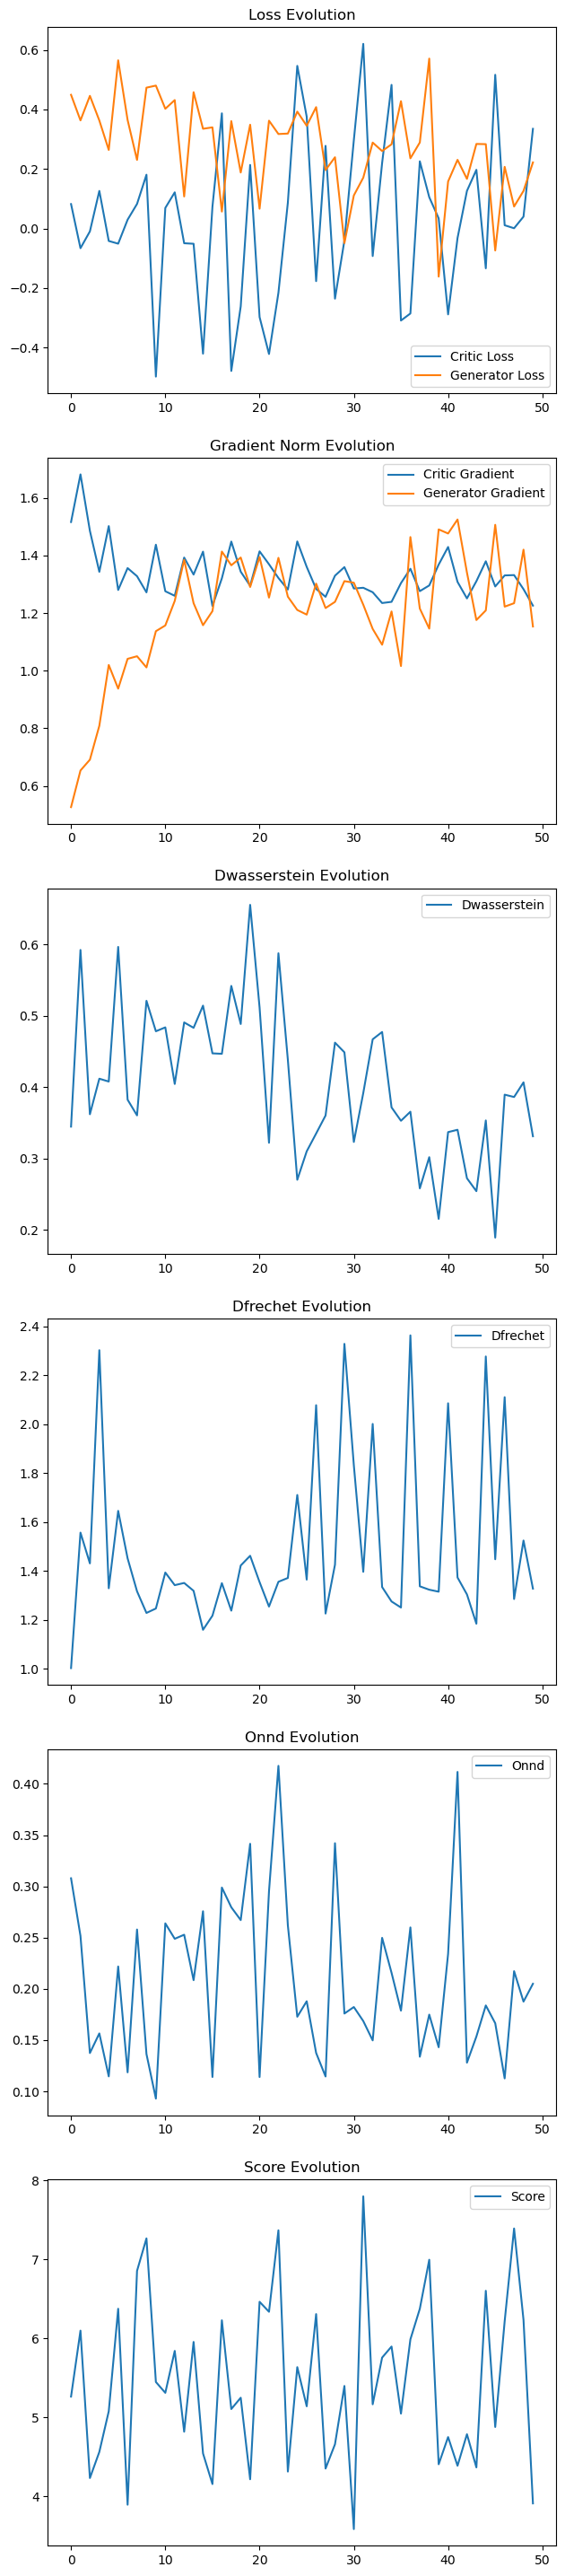

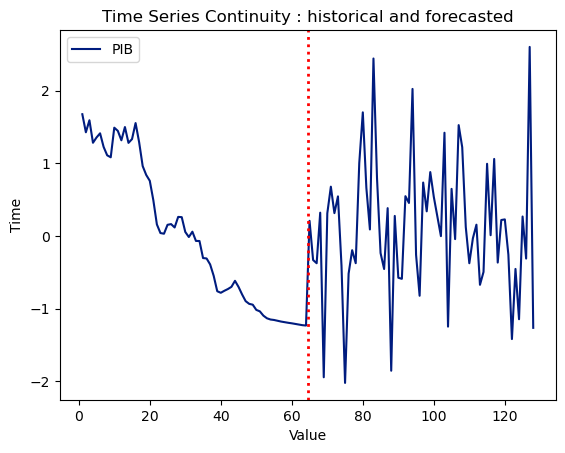

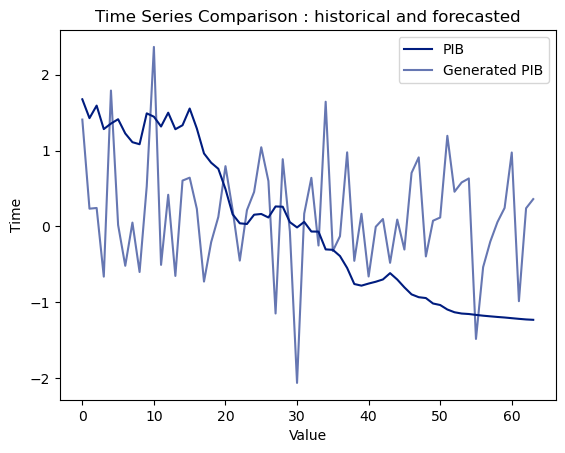

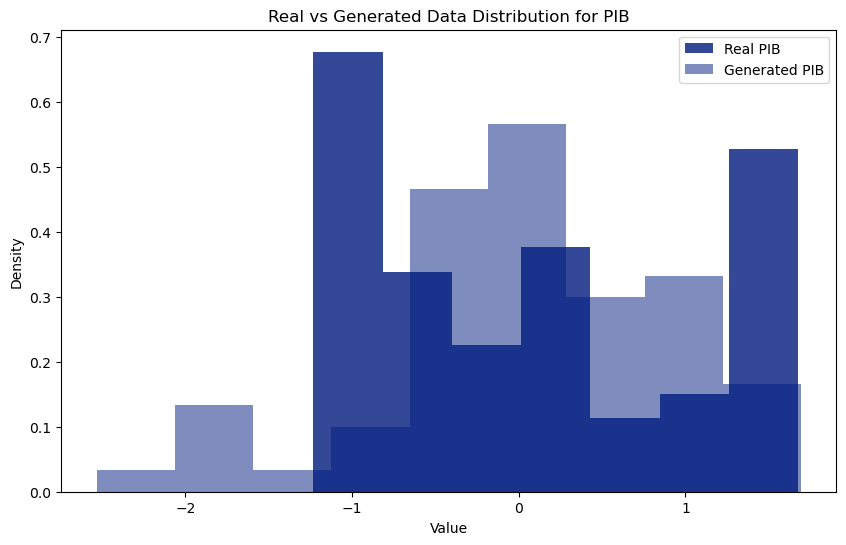

fit took 27.764759 seconds


{'dWasserstein': (0.2901273610268253, 0.30994198445085996),
 'dFrechet': (1.111720046437455, 1.7183776934091464),
 'ONND': (0.03848078568122206, 0.08937670995757986),
 'score': (4.0450408681001155, 4.731856819723271)}

In [23]:
model = WGAN()
model.set_data(data)
model.set_metrics({'dWasserstein': {'function':dWasserstein, 'metric_args': {}}, 'dFrechet': {'function':dFrechet, 'metric_args': {}}, 'ONND': {'function':ONND, 'metric_args': {}}, 'score': {'function':score, 'metric_args': {}}})
model.fit(architectures = archi, params = params, verbose = True)

In [11]:
model.fit_hyperparameters({"lr_g": [5e-6, 5e-3], "lr_c": [5e-6, 5e-3], "epochs": [50, 150], "batch_size": [8,100], "latent_dim": [1,100], "n_critic" : [1, 4], "lambda_gp" : [0.01, 1]}, n_trials = 100)

[I 2025-04-23 12:22:58,622] A new study created in memory with name: no-name-15e3a530-0019-483c-b018-f1a04ea5962d


fit took 8.624620 seconds


[I 2025-04-23 12:23:07,516] Trial 0 finished with value: 9.929107113192176 and parameters: {'lr_g': 0.0008447979056229467, 'lr_c': 0.004522197331929366, 'epochs': 96, 'batch_size': 69, 'latent_dim': 97, 'n_critic': 2, 'lambda_gp': 0.5218123545060995}. Best is trial 0 with value: 9.929107113192176.


fit took 4.222855 seconds


[I 2025-04-23 12:23:11,973] Trial 1 finished with value: 15.770831339818926 and parameters: {'lr_g': 0.0044672186137616875, 'lr_c': 0.000233946607847817, 'epochs': 71, 'batch_size': 89, 'latent_dim': 48, 'n_critic': 1, 'lambda_gp': 0.09095802408638944}. Best is trial 0 with value: 9.929107113192176.
[I 2025-04-23 12:23:17,197] Trial 2 finished with value: 10.364285165913966 and parameters: {'lr_g': 0.002678598385891763, 'lr_c': 0.0005331109364376456, 'epochs': 99, 'batch_size': 61, 'latent_dim': 39, 'n_critic': 1, 'lambda_gp': 0.40115364566942474}. Best is trial 0 with value: 9.929107113192176.


...

fit took 6.419861 seconds


[I 2025-04-23 12:38:05,106] Trial 97 finished with value: 14.408737403319941 and parameters: {'lr_g': 0.003960533587490591, 'lr_c': 0.0013979101870776483, 'epochs': 96, 'batch_size': 93, 'latent_dim': 20, 'n_critic': 1, 'lambda_gp': 0.7077758020002077}. Best is trial 69 with value: 4.227077918720244.


fit took 8.417521 seconds


[I 2025-04-23 12:38:13,849] Trial 98 finished with value: 16.474994422437533 and parameters: {'lr_g': 0.0002501362820598387, 'lr_c': 0.00039687693758210223, 'epochs': 67, 'batch_size': 60, 'latent_dim': 11, 'n_critic': 3, 'lambda_gp': 0.8621309748319254}. Best is trial 69 with value: 4.227077918720244.
[I 2025-04-23 12:38:26,879] Trial 99 finished with value: 10.270757592555283 and parameters: {'lr_g': 0.0005452047550804642, 'lr_c': 0.000788240636082269, 'epochs': 148, 'batch_size': 83, 'latent_dim': 3, 'n_critic': 2, 'lambda_gp': 0.1945815558225552}. Best is trial 69 with value: 4.227077918720244.


fit took 12.727759 seconds


In [12]:
print(model.parameters)

{'lr_g': 0.0008452165766759292, 'lr_c': 0.0014413809743508274, 'epochs': 62, 'batch_size': 36, 'latent_dim': 15, 'n_critic': 4, 'lambda_gp': 0.6531554510535417}


Epoch [1/62], C Loss: -4.5243, G Loss: 4.0530, Dwasserstein: 1.2073, Dfrechet: 2.7506, Onnd: 0.2538, Score: 5.9463
Epoch [2/62], C Loss: 0.5577, G Loss: 1.2031, Dwasserstein: 1.1266, Dfrechet: 1.8343, Onnd: 0.4961, Score: 21.6927
Epoch [3/62], C Loss: 0.1944, G Loss: 0.9109, Dwasserstein: 0.4136, Dfrechet: 1.2593, Onnd: 0.1590, Score: 5.8023
Epoch [4/62], C Loss: -0.0997, G Loss: 1.0435, Dwasserstein: 0.6374, Dfrechet: 1.3880, Onnd: 0.2217, Score: 9.2663
Epoch [5/62], C Loss: -0.3901, G Loss: 0.0201, Dwasserstein: 0.3773, Dfrechet: 2.4452, Onnd: 0.2172, Score: 6.9471
Epoch [6/62], C Loss: -0.4626, G Loss: 0.0843, Dwasserstein: 0.4031, Dfrechet: 1.4071, Onnd: 0.0972, Score: 7.6423
Epoch [7/62], C Loss: -0.7172, G Loss: -0.7647, Dwasserstein: 1.8958, Dfrechet: 5.7739, Onnd: 0.0986, Score: 16.5559
Epoch [8/62], C Loss: -1.2403, G Loss: 1.7460, Dwasserstein: 0.5612, Dfrechet: 2.6553, Onnd: 0.1769, Score: 12.2763
Epoch [9/62], C Loss: 0.2542, G Loss: -0.6593, Dwasserstein: 0.7723, Dfrechet:

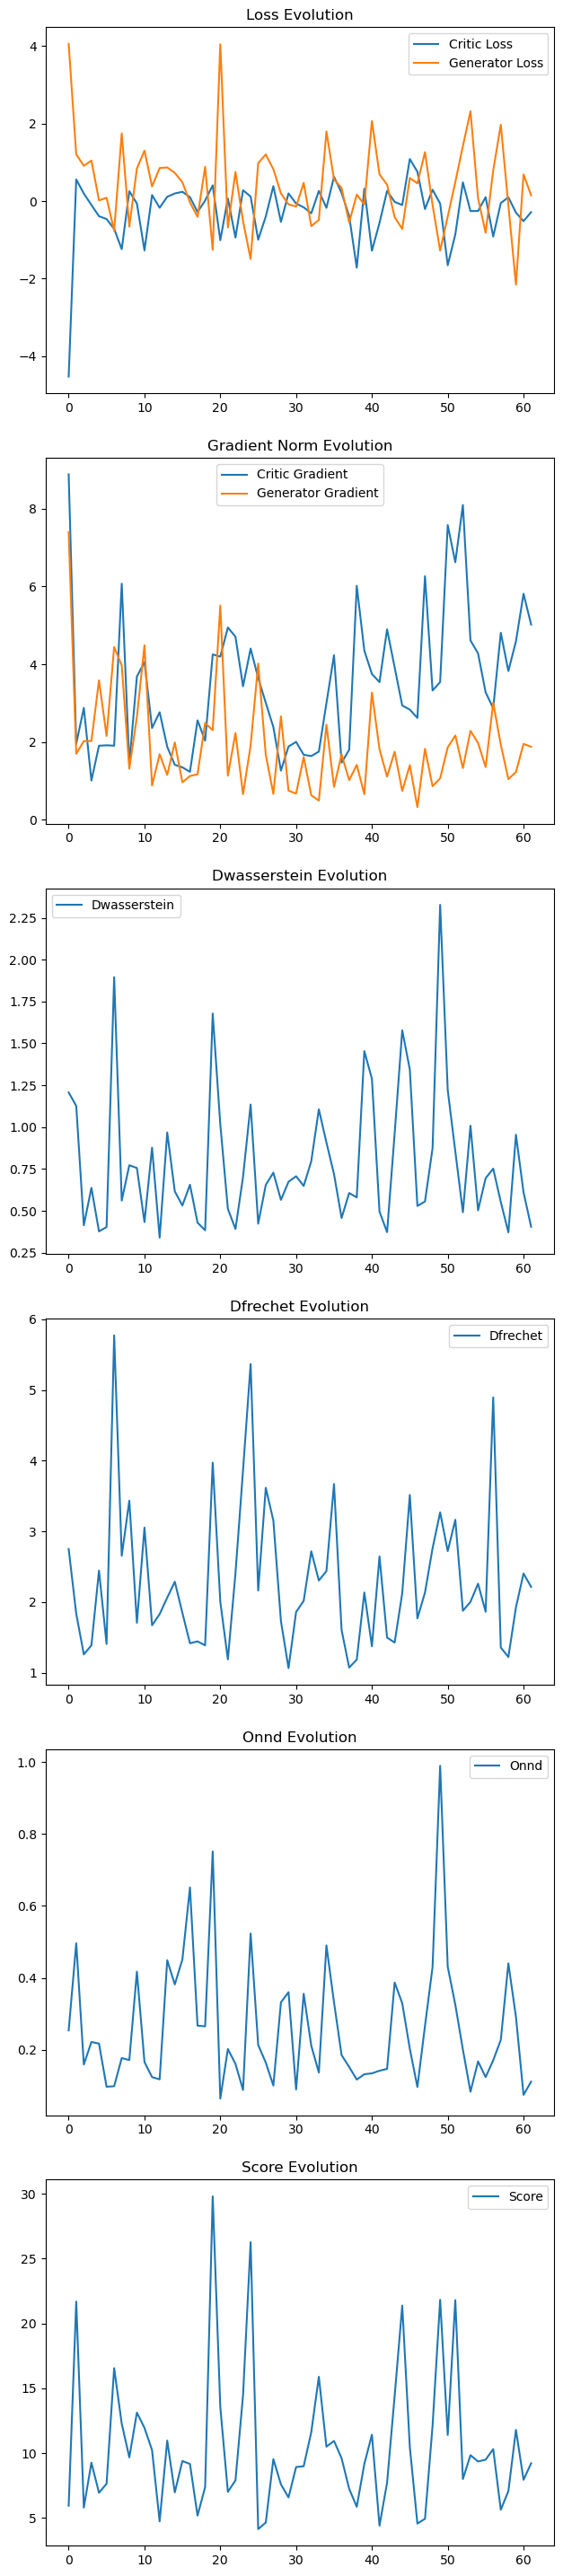

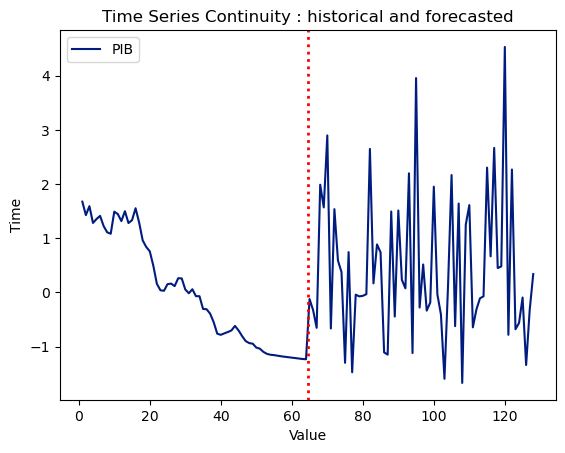

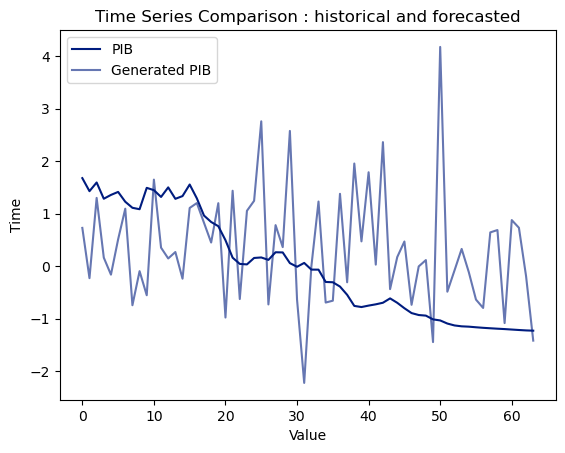

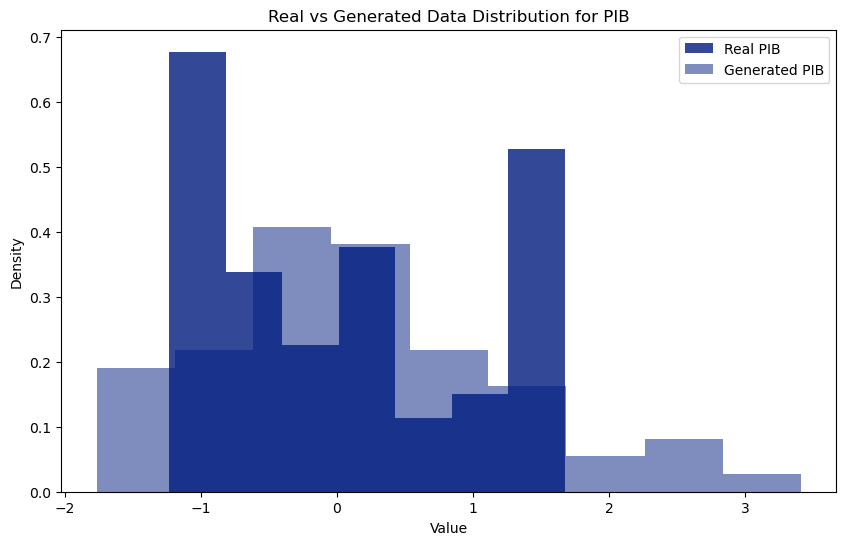

fit took 40.080121 seconds


{'dWasserstein': (0.5011905190560241, 0.41589635723194607),
 'dFrechet': (1.883760410981976, 2.5996578189486037),
 'ONND': (0.029113418258065286, 0.39479748929618386),
 'score': (7.156588248829947, 5.509325301644959)}

In [14]:
model.fit(verbose = True)

In [15]:
n = 30

w = [model.compute_val_metric(dWasserstein, {}) for _ in range(n)]
f = [model.compute_val_metric(dFrechet, {}) for _ in range(n)]
o = [model.compute_val_metric(ONND, {}) for _ in range(n)]
s = [model.compute_val_metric(score, {}) for _ in range(n)]

print("Wasserstein", sum(w)/n)
print("Fréchet", sum(f)/n)
print("ONND", sum(o)/n)
print("Score", sum(s)/n)

Wasserstein 0.5100706268490516
Fréchet 2.290000251495285
ONND 0.15345428956778392
Score 7.24523295050032
